# Birds-DMD

### Pacotes necessários / instalação

In [176]:
#pip install pydmd
#pip install opencv-python 
 

In [168]:
# ============================================================
# DMD EM VÍDEOS COLORIDOS USANDO PyDMD
# Com erro relativo, reconstrução e economia de memória
# ============================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pydmd.plotter import plot_eigs, plot_summary
from pydmd import DMD
import os


### Carregamento do vídeo

In [3]:
# OBS: lembre de importar o vídeo para o colab
video = "C:/Users/shrod/Desktop/DMD/passaro/passaro4k.mp4"
cap = cv2.VideoCapture(video)

frames = []

# detecta quantos frames tem no vídeo e a resolução
while True:
    ret, frame = cap.read()

    if not ret:
        break

    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)   # cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)  #converte pra escala de cinza // a memória do pc agradece

    frames.append(frame)

cap.release()

frames = np.array(frames)

print(frames.shape)


(1165, 1440, 2560, 3)


In [204]:
# quantidade total de quadros
k = frames.shape[0]//2
k

582

### I. Matrix de Snapshots

\begin{equation}
X_{Total}=
\begin{bmatrix}
| & | & & |\\
x_1 & x_2 & \cdots & x_{m}\\
| & | & & |
\end{bmatrix}
\label{X_dados_geral}
\end{equation}
 

 
 1. Ler vídeo colorido e montar matriz de snapshots X
 2. Se necessário, utilizar resoluções alternativas para ecnomizar memória Ram
- 320 x 180
- 640 x 360
- HD (720p): 1280 × 720 pixels
- Full HD (1080p): 1920 × 1080 pixels
- 2K: 2560 x 1440
- 4K (2160p): 3840 × 2160 pixels


In [138]:
def montar_matriz_video_colorido(
    caminho_video,
    num_frames=k,   #alternativa 100
    largura= 320*2,
    altura= 180*2
   
):
    """
    Lê um vídeo colorido, extrai uma quantidade escolhida de frames,
    redimensiona, converte para RGB, vetoriza cada frame e monta a matriz X.

    Cada coluna de X representa um frame colorido vetorizado.

    Dimensão de X:

        (altura * largura * 3) x num_frames
    """

    cap = cv2.VideoCapture(caminho_video)

    if not cap.isOpened():
        raise ValueError("Erro: não foi possível abrir o vídeo.")

    frames = []
    contador = 0

    fps = cap.get(cv2.CAP_PROP_FPS)

    while contador < num_frames:

        ret, frame = cap.read()

        if not ret:
            break

        # Redimensiona o frame
        frame = cv2.resize(frame, (largura, altura))

        # OpenCV lê em BGR; convertemos para RGB
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        # Normalização para [0, 1]
        frame_rgb = frame_rgb.astype(np.float64) / 255.0

        # Vetoriza o frame colorido
        vetor = frame_rgb.flatten()

        frames.append(vetor)

        contador += 1

    cap.release()

    if len(frames) == 0:
        raise ValueError("Nenhum frame foi lido.")

    # Cada coluna será um frame
    X = np.array(frames).T

    return X, altura, largura, 3, len(frames), fps

X = montar_matriz_video_colorido(video)
print(X, '->Matriz de dados, altura do video, largura do video, canais, quantidade de quadros (k), fps ')


(array([[0.35686275, 0.35686275, 0.35686275, ..., 0.27058824, 0.26666667,
        0.26666667],
       [0.45882353, 0.45882353, 0.45882353, ..., 0.35686275, 0.35686275,
        0.35686275],
       [0.25490196, 0.25490196, 0.25490196, ..., 0.19607843, 0.18431373,
        0.18431373],
       ...,
       [0.67058824, 0.67058824, 0.67058824, ..., 0.5254902 , 0.5254902 ,
        0.52941176],
       [0.70588235, 0.70588235, 0.70588235, ..., 0.57254902, 0.57254902,
        0.57254902],
       [0.53333333, 0.53333333, 0.53333333, ..., 0.39607843, 0.39607843,
        0.40784314]], shape=(691200, 582)), 360, 640, 3, 582, 59.94005994005994) ->Matriz de dados, altura do video, largura do video, canais, quantidade de quadros (k), fps 


 3. Aplicar DMD usando PyDMD 


\begin{equation}
{X}
\approx
\begin{bmatrix}
\,|\, &        & \,|\, \\
\phi_1 & \cdots & \phi_r \\
\,|\, &        & \,|\, 
\end{bmatrix}
\begin{bmatrix}
b_1 &        & 0 \\
    & \ddots &   \\
0   &        & b_r
\end{bmatrix}
\begin{bmatrix}
e^{\omega_1 t_1} & \cdots & e^{\omega_1 t_m} \\
\vdots           & \ddots & \vdots \\
e^{\omega_r t_1} & \cdots & e^{\omega_r t_m}.
\end{bmatrix}
%=\Phi\,\mathrm{diag}(\mathbf{b})\,T(\omega).
\label{dmd:matrix_X}
\end{equation}

In [180]:

def aplicar_dmd_pydmd(X, r):
    """
    Aplica DMD usando a biblioteca PyDMD.
    O parâmetro svd_rank = r define o número de modos utilizados.
    """

    dmd = DMD(svd_rank=r)

    dmd.fit(X)

    X_rec = dmd.reconstructed_data.real

    return X_rec, dmd

r = 3
X_rec, dmd = aplicar_dmd_pydmd(X[0],r)


Resumo dos modos e autovalores

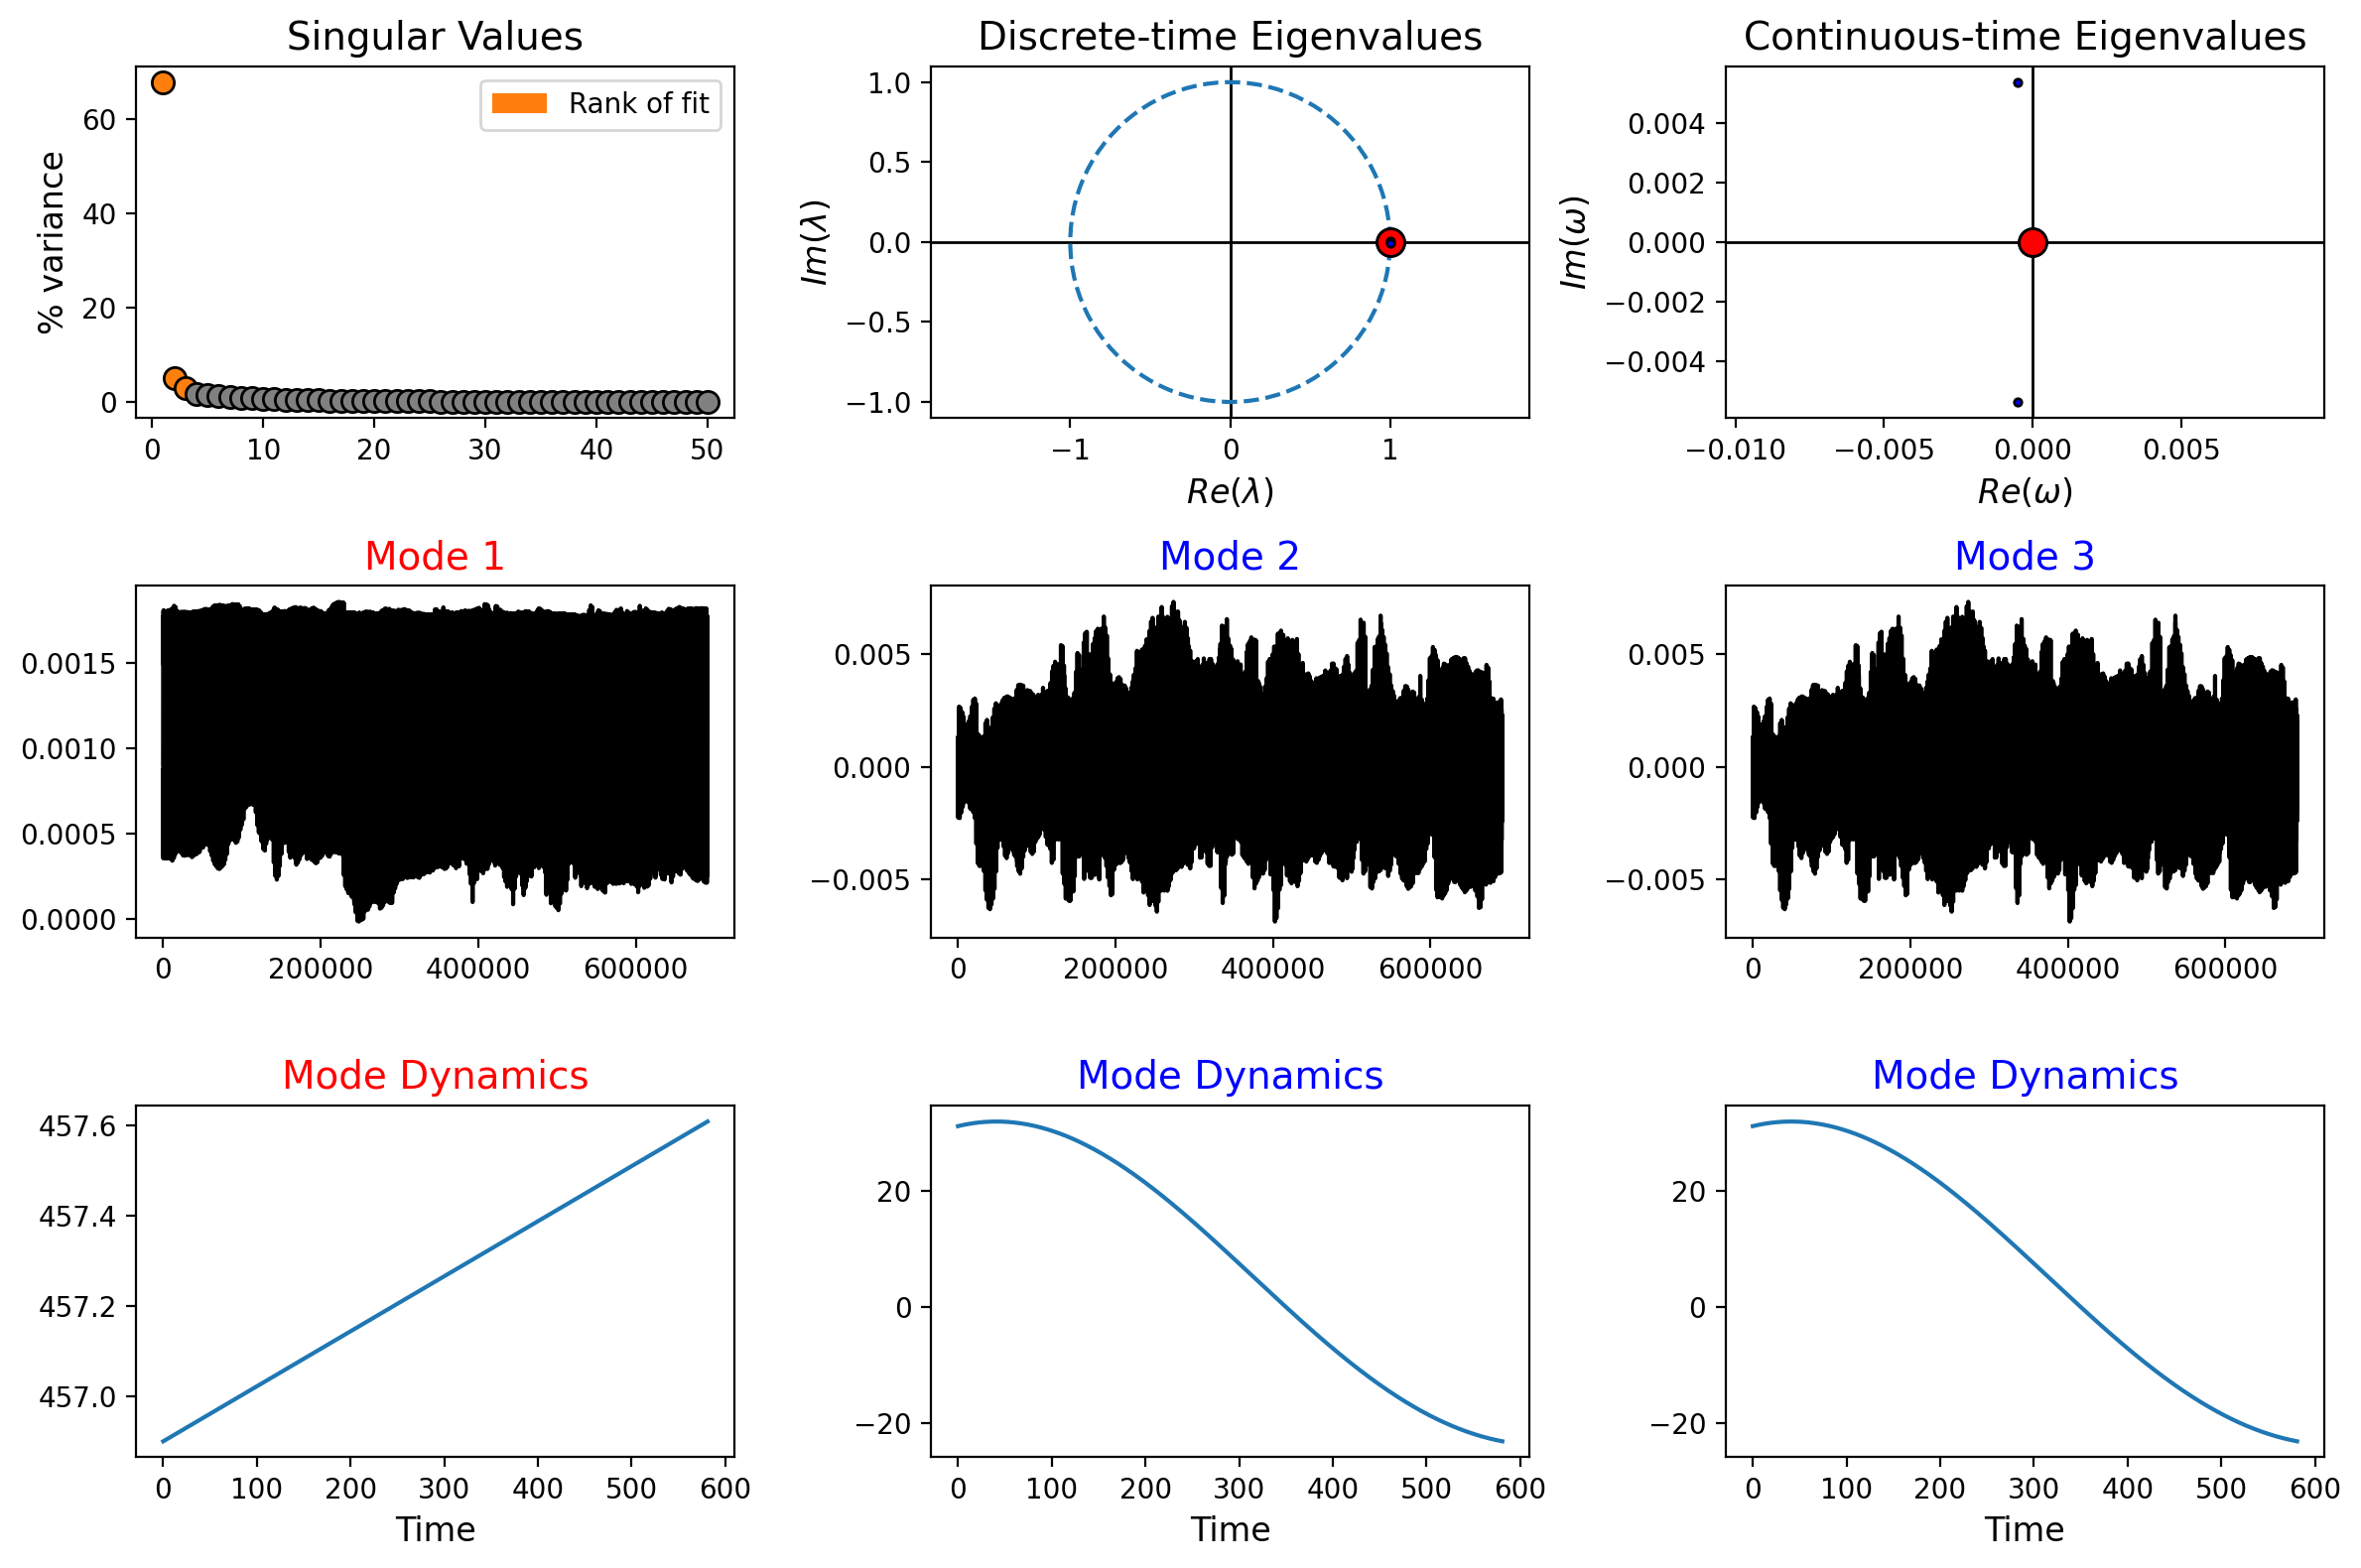

In [181]:
plot_summary(dmd)

### II Métricas e Estimativas

4. Calcular erro relativo de reconstrução


\begin{equation}
E=
\frac{||X-X_{DMD}||_F}
{||X||_F}
\end{equation}

In [141]:

def calcular_erro_relativo(X, X_rec):
    """
    Erro relativo de Frobenius:

        ||X - X_rec||_F / ||X||_F
    """

    erro = np.linalg.norm(X - X_rec, "fro")
    norma = np.linalg.norm(X, "fro")

    return erro / norma


#erro = calcular_erro_relativo(X[0], X_rec)
#erro

5. Estimar memória economizada pela representação DMD

In [142]:
def estimar_memoria_dmd(X, r, bytes_por_valor=8):
    """
    Estima a economia de memória da representação DMD.

    A matriz original X armazena:

        m * n valores

    A representação DMD reduzida armazena aproximadamente:

        m*r + r + r*n valores

    onde:
        m = quantidade de pixels vezes canais de cor
        n = número de frames
        r = número de modos DMD

    bytes_por_valor:
        8 -> float64
        4 -> float32
    """

    m, n = X.shape

    elementos_original = m * n

    elementos_dmd = m*r + r + r*n

    memoria_original_bytes = elementos_original * bytes_por_valor
    memoria_dmd_bytes = elementos_dmd * bytes_por_valor

    memoria_original_MB = memoria_original_bytes / (1024**2)
    memoria_dmd_MB = memoria_dmd_bytes / (1024**2)

    memoria_original_GB = memoria_original_bytes / (1024**3)
    memoria_dmd_GB = memoria_dmd_bytes / (1024**3)

    economia_MB = memoria_original_MB - memoria_dmd_MB

    economia_percentual = 100 * (
        1 - memoria_dmd_bytes / memoria_original_bytes
    )

    taxa_compressao = memoria_original_bytes / memoria_dmd_bytes

    return {
        "m": m,
        "n": n,
        "r": r,
        "elementos_original": elementos_original,
        "elementos_dmd": elementos_dmd,
        "memoria_original_MB": memoria_original_MB,
        "memoria_dmd_MB": memoria_dmd_MB,
        "memoria_original_GB": memoria_original_GB,
        "memoria_dmd_GB": memoria_dmd_GB,
        "economia_MB": economia_MB,
        "economia_percentual": economia_percentual,
        "taxa_compressao": taxa_compressao
    }

In [143]:
estimar_memoria_dmd(X[0],r)

{'m': 691200,
 'n': 582,
 'r': 2,
 'elementos_original': 402278400,
 'elementos_dmd': 1383566,
 'memoria_original_MB': 3069.140625,
 'memoria_dmd_MB': 10.555770874023438,
 'memoria_original_GB': 2.9972076416015625,
 'memoria_dmd_GB': 0.010308369994163513,
 'economia_MB': 3058.5848541259766,
 'economia_percentual': 99.65606753929617,
 'taxa_compressao': 290.75475980184535}

6. Salvar vídeo reconstruído colorido 


In [144]:
def salvar_video_colorido(
    X_rec,
    caminho_saida,
    altura,
    largura,
    canais=3,
    fps=59.94005994005994
):
    """
    Recebe a matriz reconstruída X_rec e salva como vídeo colorido.
    """

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")

    out = cv2.VideoWriter(
        caminho_saida,
        fourcc,
        fps,
        (largura, altura),
        isColor=True
    )

    for k in range(X_rec.shape[1]):

        frame = X_rec[:, k].reshape((altura, largura, canais))

        frame = np.clip(frame, 0, 1)

        frame = (frame * 255).astype(np.uint8)

        # OpenCV salva em BGR
        frame_bgr = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)

        out.write(frame_bgr)

    out.release()
 
caminho_saida = 'C:/Users/shrod/Desktop/DMD/passaro/resultados_dmd/rec.mp4'
altura = 180*2
largura = 320*2
canais=3
fps= 59 

salvar_video_colorido(
    X_rec,
    caminho_saida,
    altura,
    largura,
    canais,
    fps
)

### III Comparação: Original x Recontruído 

Vetor de tempos $t_k$

In [149]:
tk = np.linspace(0,k,k)

#print(tk[::70])
indices = []

for i in range(  len(tk[::70])):
    indices.append(int(tk[::60][i]) )
    
indices

[0, 60, 120, 180, 240, 300, 360, 420, 480]

7. Visualizar frames originais e reconstruídos 

In [203]:
def comparar_frames(
    X,
    X_rec,
    altura,
    largura,
    canais=3,
    indices=[0,120,360, 480]  #[0, 50, 100, 150]
):
    """
    Exibe alguns frames originais e reconstruídos lado a lado.
    """

    plt.figure(figsize=(12, 3 * len(indices)))

    for i, idx in enumerate(indices):

        if idx >= X.shape[1]:
            continue

        frame_original = X[:, idx].reshape((altura, largura, canais))
        frame_rec = X_rec[:, idx].reshape((altura, largura, canais))

        frame_original = np.clip(frame_original, 0, 1)
        frame_rec = np.clip(frame_rec, 0, 1)

        plt.subplot(len(indices), 2, 2*i + 1)
        plt.imshow(frame_original)
        plt.title(f"Original - Frame {idx}")
        plt.axis("off")

        plt.subplot(len(indices), 2, 2*i + 2)
        plt.imshow(frame_rec)
        plt.title(f"Reconstruído - Frame {idx}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()



Plotagem das imagens originais e reconstruídas para algum frame

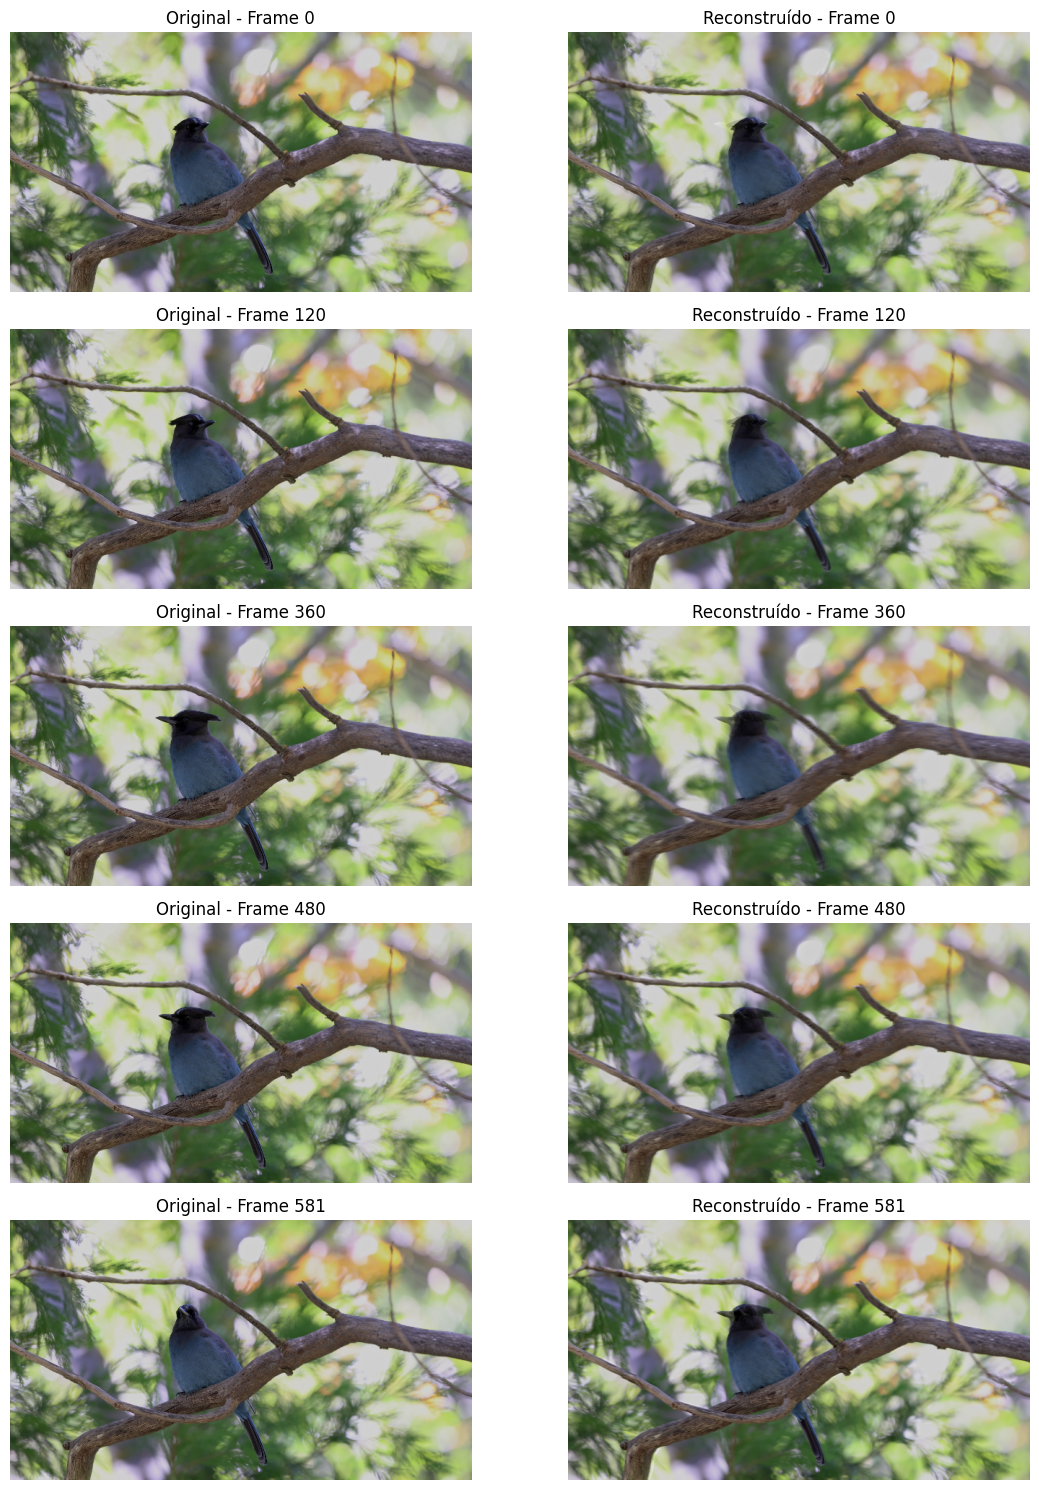

In [202]:
comparar_frames(
    X[0],
    X_rec,altura, largura)
 

8. Aplicar DMD para vários valores de r

In [152]:
def analisar_varios_r(
    X,
    altura,
    largura,
    canais,
    fps,
    valores_r,
    pasta_saida="resultados_dmd",
    bytes_por_valor=8
):
    """
    Aplica DMD para diferentes valores de r.
    Salva os vídeos reconstruídos.
    Calcula erro relativo e economia de memória.
    """

    os.makedirs(pasta_saida, exist_ok=True)

    resultados = []

    erros = []
    economias = []
    reducoes = []
    taxas = []

    for r in valores_r:

        print("\n" + "=" * 70)
        print(f"Aplicando DMD com r = {r}")
        print("=" * 70)

        X_rec, dmd = aplicar_dmd_pydmd(X, r)

        erro = calcular_erro_relativo(X, X_rec)

        info_memoria = estimar_memoria_dmd(
            X,
            r,
            bytes_por_valor=bytes_por_valor
        )

        caminho_saida = os.path.join(
            pasta_saida,
            f"video_reconstruido_DMD_r_{r}.mp4"
        )

        salvar_video_colorido(
            X_rec,
            caminho_saida,
            altura,
            largura,
            canais,
            fps=fps
        )

        resultados.append({
            "r": r,
            "erro": erro,
            "memoria_original_MB": info_memoria["memoria_original_MB"],
            "memoria_dmd_MB": info_memoria["memoria_dmd_MB"],
            "economia_MB": info_memoria["economia_MB"],
            "economia_percentual": info_memoria["economia_percentual"],
            "taxa_compressao": info_memoria["taxa_compressao"],
            "arquivo": caminho_saida
        })

        erros.append(erro)
        economias.append(info_memoria["economia_MB"])
        reducoes.append(info_memoria["economia_percentual"])
        taxas.append(info_memoria["taxa_compressao"])

        print(f"Erro relativo: {erro:.6f}")
        print(f"Memória original: {info_memoria['memoria_original_MB']:.2f} MB")
        print(f"Memória DMD: {info_memoria['memoria_dmd_MB']:.2f} MB")
        print(f"Economia: {info_memoria['economia_MB']:.2f} MB")
        print(f"Economia percentual: {info_memoria['economia_percentual']:.2f}%")
        print(f"Taxa de compressão: {info_memoria['taxa_compressao']:.2f} vezes")
        print(f"Vídeo reconstruído salvo em: {caminho_saida}")

    return resultados, erros, economias, reducoes, taxas


In [153]:
valores_r = [1, 2, 3, 5, 10, 15, 20]

resultados, erros, economias, reducoes, taxas = analisar_varios_r(
    X[0],
    altura,
    largura,
    canais,
    fps,
    valores_r=valores_r,
    pasta_saida="resultados_dmd",
    bytes_por_valor=8
)


Aplicando DMD com r = 1
Erro relativo: 0.104436
Memória original: 3069.14 MB
Memória DMD: 5.28 MB
Economia: 3063.86 MB
Economia percentual: 99.83%
Taxa de compressão: 581.51 vezes
Vídeo reconstruído salvo em: resultados_dmd\video_reconstruido_DMD_r_1.mp4

Aplicando DMD com r = 2
Erro relativo: 0.078567
Memória original: 3069.14 MB
Memória DMD: 10.56 MB
Economia: 3058.58 MB
Economia percentual: 99.66%
Taxa de compressão: 290.75 vezes
Vídeo reconstruído salvo em: resultados_dmd\video_reconstruido_DMD_r_2.mp4

Aplicando DMD com r = 3
Erro relativo: 0.063149
Memória original: 3069.14 MB
Memória DMD: 15.83 MB
Economia: 3053.31 MB
Economia percentual: 99.48%
Taxa de compressão: 193.84 vezes
Vídeo reconstruído salvo em: resultados_dmd\video_reconstruido_DMD_r_3.mp4

Aplicando DMD com r = 5
Erro relativo: 0.047826
Memória original: 3069.14 MB
Memória DMD: 26.39 MB
Economia: 3042.75 MB
Economia percentual: 99.14%
Taxa de compressão: 116.30 vezes
Vídeo reconstruído salvo em: resultados_dmd\vide

9. Plotar gráficos dos resultados 


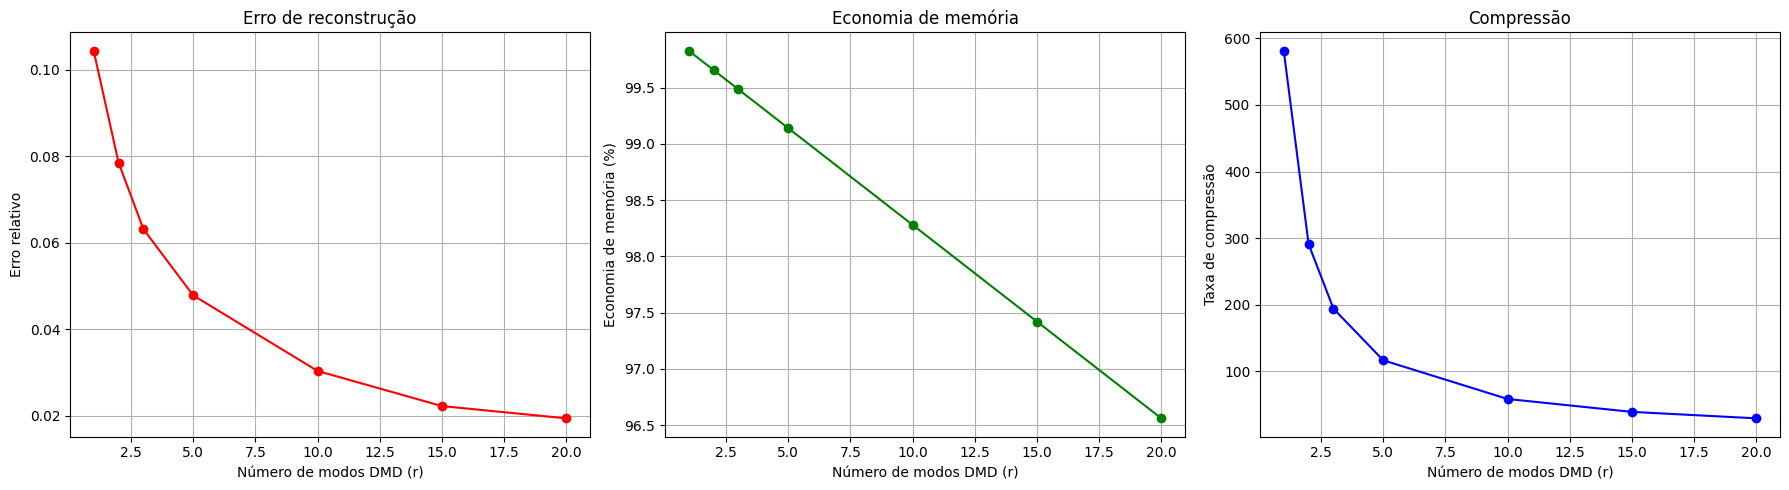

In [164]:
def plotar_resultados(valores_r, erros, economias, reducoes, taxas):

    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    # Erro relativo
    axs[0].plot(valores_r, erros, marker="o", color='r')
    axs[0].set_xlabel("Número de modos DMD (r)")
    axs[0].set_ylabel("Erro relativo")
    axs[0].set_title("Erro de reconstrução")
    axs[0].grid(True)

    # Economia de memória
    axs[1].plot(valores_r, reducoes, marker="o", color='g')
    axs[1].set_xlabel("Número de modos DMD (r)")
    axs[1].set_ylabel("Economia de memória (%)")
    axs[1].set_title("Economia de memória")
    axs[1].grid(True)

    # Taxa de compressão
    axs[2].plot(valores_r, taxas, marker="o", color='b')
    axs[2].set_xlabel("Número de modos DMD (r)")
    axs[2].set_ylabel("Taxa de compressão")
    axs[2].set_title("Compressão")
    axs[2].grid(True)

    plt.tight_layout()
    plt.show()

plotar_resultados(valores_r, erros, economias, reducoes, taxas)